## Fraud risk prediction to handle fraudulent on company

* ### 1. ML models for classifier target fraud & no fraud
* ### 2. LLM for explanation the reason about the ML models relation
* ### 3. Agentic AI to prove action, recommendation based on the case

## Import library

In [23]:
import pandas as pd
import numpy as np

from pathlib import Path
import os
from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

## Load configuration

In [24]:
# Configuration
BASE_PATH = Path.cwd().resolve().parents[1]
PROD_PATH = BASE_PATH / "credit_risk_production"
DATA_PATH = PROD_PATH / "database" / "data" / "merged_credit_risk_data.parquet"
FEATURES = PROD_PATH / "database" / "data" / "features_data.parquet"

ENV_PATH = PROD_PATH / ".env"
load_dotenv(dotenv_path=ENV_PATH)


True

In [25]:
# Load the dataset
pd.set_option('display.max_columns', None)
df = pd.read_parquet(DATA_PATH)
features = pd.read_parquet(FEATURES)

In [26]:
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.0,0,0,0,0,1,0,4,1,4,0,72,18,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.0,0,0,0,1,0,0,0,0,1,0,7,7,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.0,1,1,0,6,1,0,0,2,6,0,47,2,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,1,0,1.00,0.0,1,0,0,0,0,0,0,0,1,1,5,5,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.0,0,1,0,0,0,0,0,3,0,2,131,32,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [27]:
df[['PROSPECTID', 'PL_TL']].sample(20)

,PROSPECTID,PL_TL
49715,49716,2
43072,43073,0
23262,23263,2
35032,35033,0
18277,18278,0
48440,48441,0
8874,8875,0
50940,50941,0
49132,49133,0
2151,2152,0


## Categorical checking fraud & no fraud by: 
* ### Credit_Score, Approved_Flag, CC_enq, CC_enq_L12m
* ### (Secured_TL - Unsecured_TL), PL_enq, PL_enq_L6m, PL_enq_L12m

In [28]:
# Cateogirical columns needed for fraud risk analysis
IMPORTANCE_COLS = ["Credit_Score", "Approved_Flag", "CC_enq_L6m", "CC_enq_L12m", "Secured_TL", "Unsecured_TL", "PL_enq", "PL_enq_L6m", "PL_enq_L12m"]

# Into dataframe for analysis
df_new = df[IMPORTANCE_COLS].copy()
print(f"Shape of the dataframe: {df_new.shape}")

Shape of the dataframe: (51336, 9)


In [29]:
df_new["Credit_Score"]

0        696
1        685
2        693
3        673
4        753
        ... 
51331    650
51332    702
51333    661
51334    686
51335    681
Name: Credit_Score, Length: 51336, dtype: int64

## Feature engineering to get median of secured accounts

In [30]:
# Apply threshold to stabilize the values of Secured_Account with numpy
THRESHOLD = 1

diff = df_new["Secured_TL"] - df_new["Unsecured_TL"]
df_new["Secured_Account"] = np.where(diff > THRESHOLD, 1, 0)
print(f"Amount of Unsecured & Secured Accounts:\n{df_new['Secured_Account'].value_counts()}")

Amount of Unsecured & Secured Accounts:
Secured_Account
0    37539
1    13797
Name: count, dtype: int64


## Data visualization

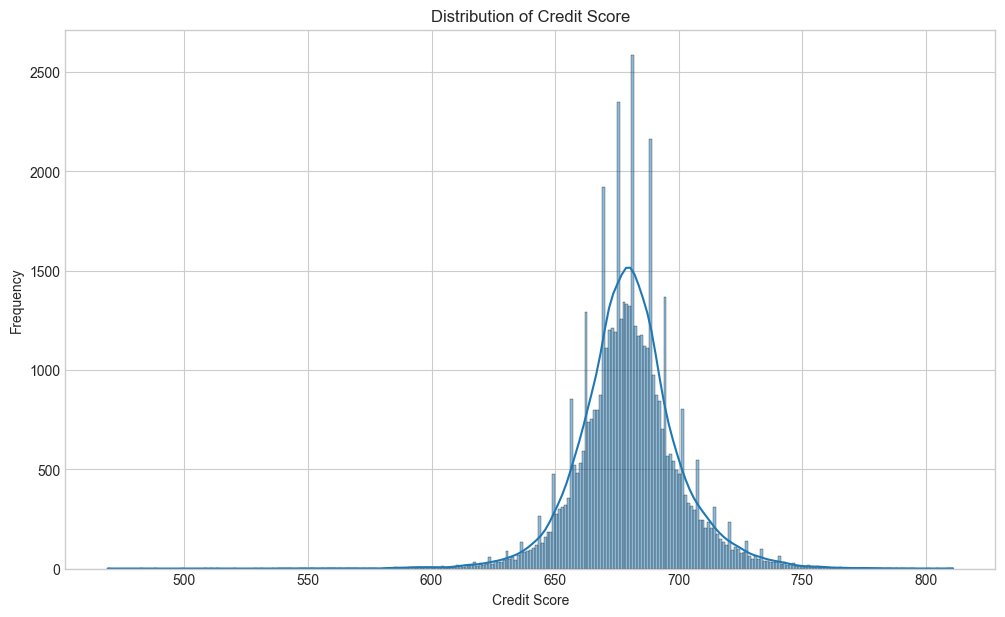

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distribution of Credit_Score
fig, ax = plt.subplots(figsize=(12, 7))
sns.histplot(df['Credit_Score'], kde=True, ax=ax)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

Amount of Unsecured & Secured Accounts:
Secured_Account
0    37539
1    13797
Name: count, dtype: int64


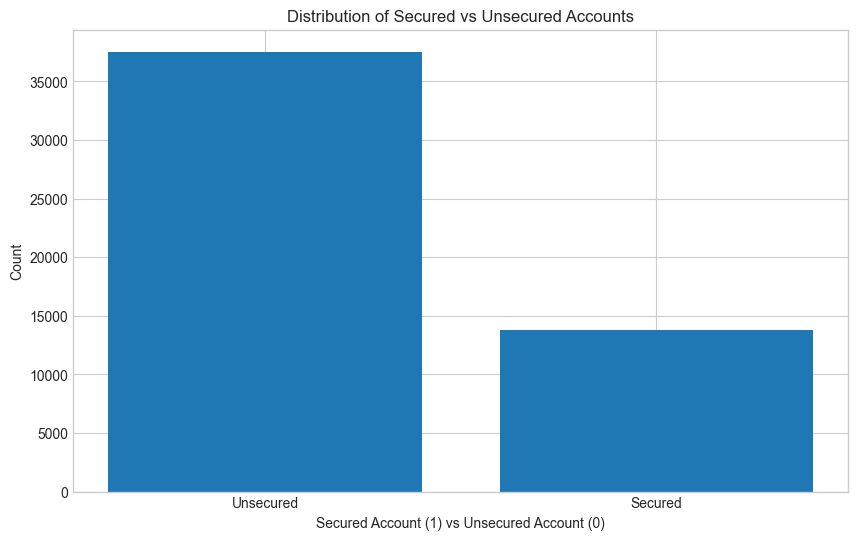

In [32]:
print(f"Amount of Unsecured & Secured Accounts:\n{df_new['Secured_Account'].value_counts()}")

plt.figure(figsize=(10, 6))
plt.bar(df_new["Secured_Account"].value_counts().index, df_new["Secured_Account"].value_counts().values)
plt.title('Distribution of Secured vs Unsecured Accounts')
plt.xlabel('Secured Account (1) vs Unsecured Account (0)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Unsecured', 'Secured'])
plt.show()

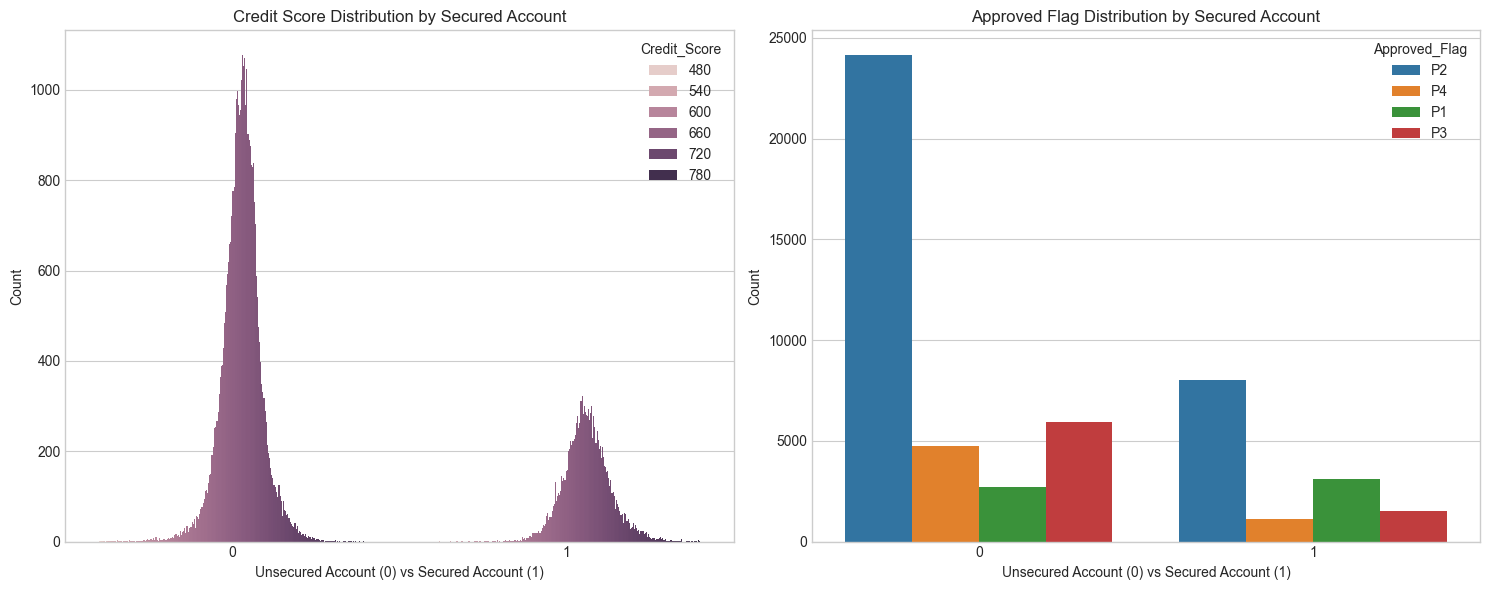

In [33]:
# Leverage of the Secured_Account features to Approved_Flag & Credit_Score columns
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(x='Secured_Account', hue='Credit_Score', data=df_new, ax=ax[0])
ax[0].set_xlabel('Unsecured Account (0) vs Secured Account (1)')
ax[0].set_title('Credit Score Distribution by Secured Account')
ax[0].set_ylabel('Count')

sns.countplot(x='Secured_Account', hue='Approved_Flag', data=df_new, ax=ax[1])
ax[1].set_title('Approved Flag Distribution by Secured Account')
ax[1].set_xlabel('Unsecured Account (0) vs Secured Account (1)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [34]:
print("--- NUMERICAL FEATURE DISTRIBUTION ---")
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(df_new.describe(percentiles=percentiles).T[["min", "50%", "75%", "90%", "95%", "99%", "max"]])

# Inspect categorical value counts (Approved_Flag)
print("\n--- APPROVED FLAG DISTRIBUTION ---")
print(df_new["Approved_Flag"].value_counts(dropna=False))

--- NUMERICAL FEATURE DISTRIBUTION ---
                     min    50%    75%    90%    95%     99%    max
Credit_Score       469.0  680.0  691.0  704.0  714.0  735.65  811.0
CC_enq_L6m      -99999.0    0.0    0.0    0.0    1.0    3.00   17.0
CC_enq_L12m     -99999.0    0.0    0.0    1.0    1.0    5.00   24.0
Secured_TL           0.0    1.0    3.0    7.0   12.0   29.00  235.0
Unsecured_TL         0.0    1.0    2.0    5.0    8.0   15.00   55.0
PL_enq          -99999.0    0.0    1.0    3.0    5.0   10.00   46.0
PL_enq_L6m      -99999.0    0.0    0.0    1.0    2.0    6.00   44.0
PL_enq_L12m     -99999.0    0.0    1.0    2.0    3.0    8.00   44.0
Secured_Account      0.0    0.0    1.0    1.0    1.0    1.00    1.0

--- APPROVED FLAG DISTRIBUTION ---
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


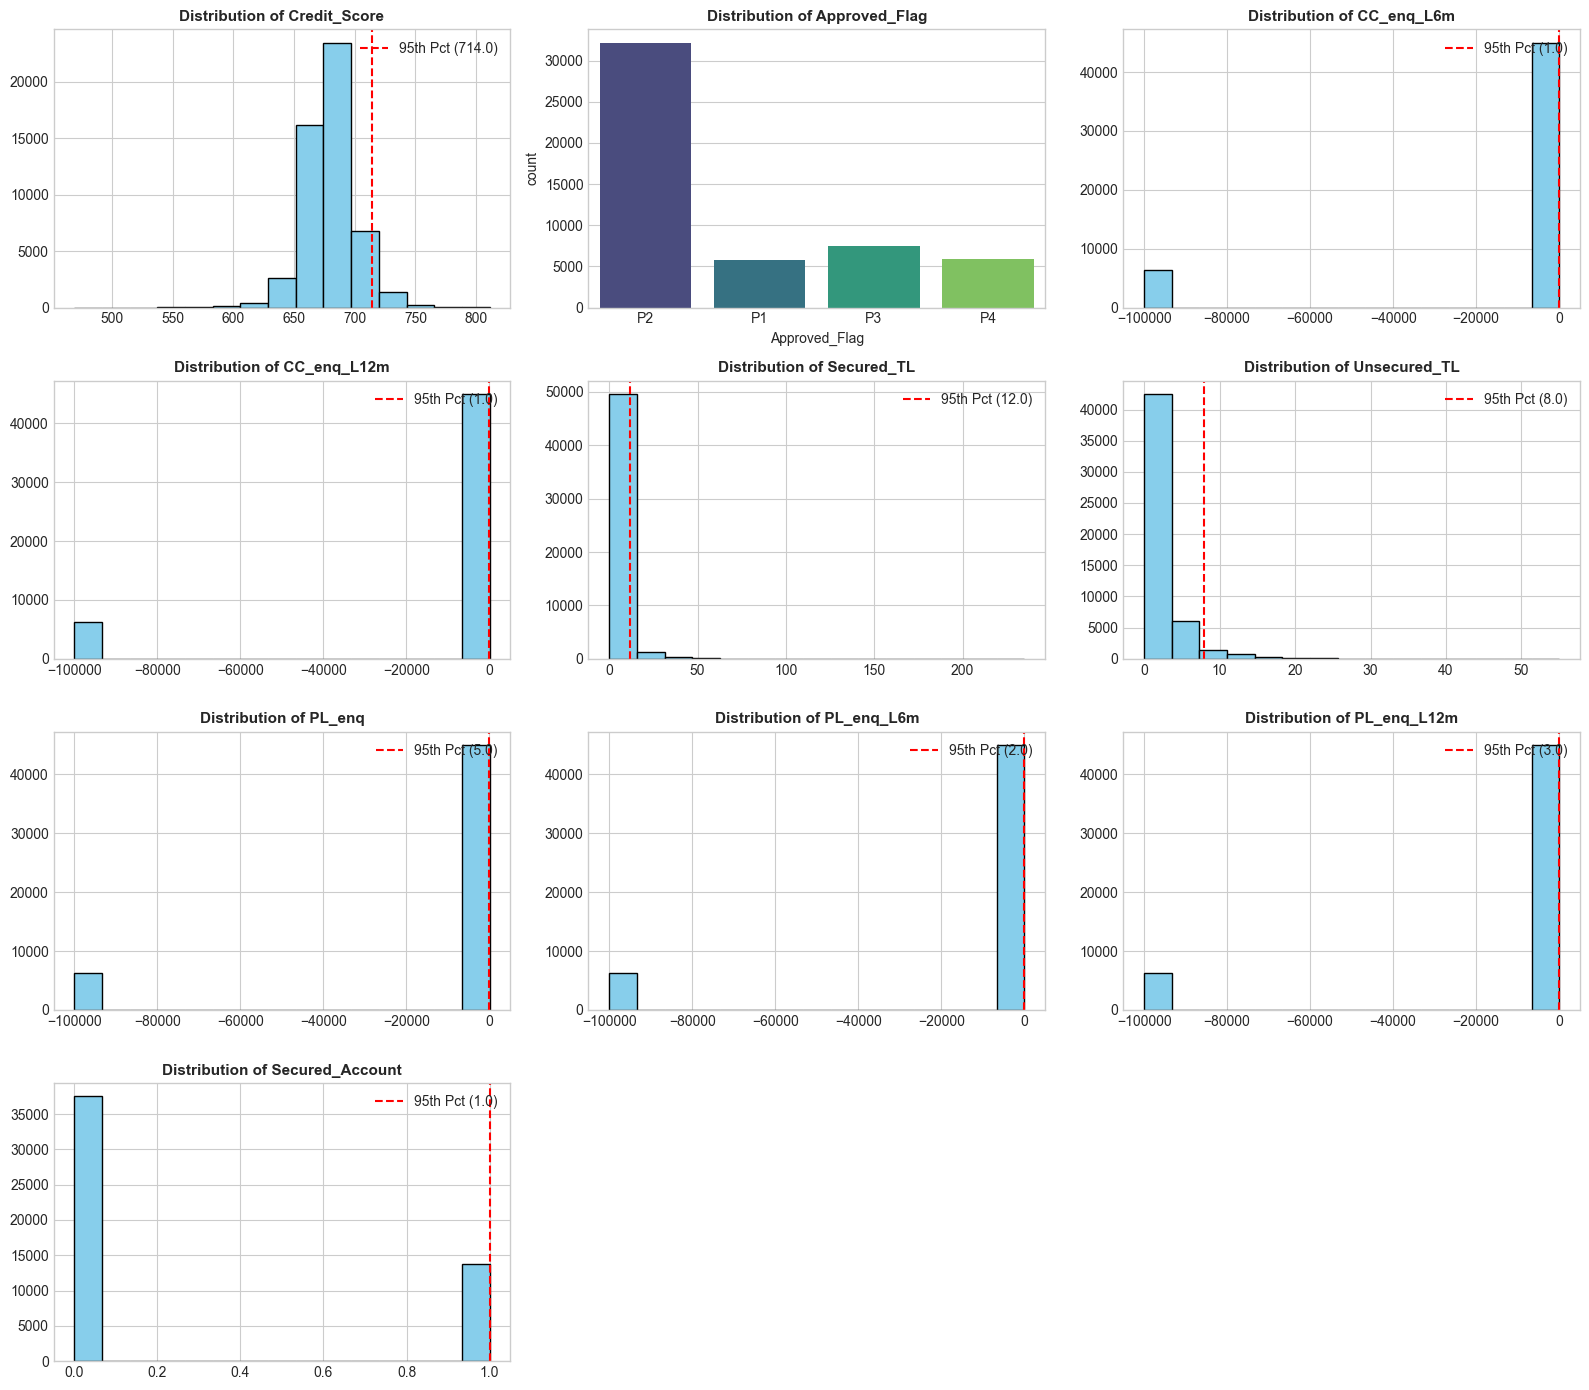

In [35]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use subset for fast rendering
num_cols = len(df_new.columns)

# 2. Dynamic grid setup
ncols = 3
nrows = math.ceil(num_cols / ncols)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

# 3. Pre-calculate 95th percentiles in vectorized bulk (Fast!)
p95_series = df_new.select_dtypes(include="number").quantile(0.95)

for idx, col in enumerate(df_new.columns):
    ax = axes[idx]

    if col == "Approved_Flag":
        sns.countplot(data=df_new, x=col, ax=ax, palette="viridis")
    else:
        # Fast histogram without discrete bin evaluation
        ax.hist(df_new[col].dropna(), bins=15, color='skyblue', edgecolor='black')
        
        # Draw pre-calculated percentile
        if col in p95_series:
            p95 = p95_series[col]
            ax.axvline(p95, color="red", linestyle="--", label=f"95th Pct ({p95:.1f})")
            ax.legend(loc="upper right")

    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')

# Hide unused empty plots
for i in range(num_cols, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [36]:
(df_new["Secured_Account"] == 1).astype(int).value_counts()

Secured_Account
0    37539
1    13797
Name: count, dtype: int64

## Transform data

In [37]:
# Build fraud column based on the group by Secured account to all columns

# Handle sentinel missing values on out of range
valid_pl_l6m = df_new["PL_enq_L6m"].replace(-99999, 0)
valid_cc_l6m = df_new["CC_enq_L6m"].replace(-99999, 0)
valid_pl_l12m = df_new["PL_enq_L12m"].replace(-99999, 0)
valid_cc_l12m = df_new["CC_enq_L12m"].replace(-99999, 0)

# Condition A: Approved despite unusually high inquiries (> 3)
suspicious_inquiries = (
    (df_new["Approved_Flag"].isin(["P1", "P2"])) &
    (valid_pl_l6m >= 0) & (valid_cc_l6m >= 0) &
    (valid_pl_l12m >= 0) & (valid_cc_l12m >= 0) &
    (df_new["Secured_Account"] == 1)
)

# Condition B: High-risk approval with low credit score (< 600 or 650)
suspicious_credit_profile = (
    (df_new["Approved_Flag"].isin(["P3", "P4"])) &
    (df_new["Credit_Score"] <= 700) &
    (valid_cc_l6m >= 0) & (valid_pl_l6m >= 0) &
    (valid_cc_l12m >= 1) & (valid_pl_l12m >= 0) &
    (df_new["Secured_Account"] == 1)
)

# Combine condition into a single fraud risk column
fraud_condition = suspicious_inquiries | suspicious_credit_profile
df_new["Fraud"] = np.where(fraud_condition, 1, 0)

# Summary
print("--- FRAUD RISK SUMMARY ---")
print(df_new["Fraud"].value_counts())
print(f"\nFraud Rate: {df_new['Fraud'].mean():.2%}%")

--- FRAUD RISK SUMMARY ---
Fraud
0    39853
1    11483
Name: count, dtype: int64

Fraud Rate: 22.37%%


In [38]:
df_new["Credit_Score"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    51336.000000
mean       679.859222
std         20.502764
min        469.000000
25%        669.000000
50%        680.000000
75%        691.000000
90%        704.000000
95%        714.000000
99%        735.650000
max        811.000000
Name: Credit_Score, dtype: float64

## Interpratation New Database

In [39]:
# Interprate the fraud in df_new into df
df["Fraud"] = df_new["Fraud"]
print(f"Final Shape Dataset={df.shape}")
print(f"Mount of null values in data: {df.isnull().sum().sum()}")
print(f"Value counts of Fraud column:\n{df['Fraud'].value_counts()}")
display(df.head())

Final Shape Dataset=(51336, 88)
Mount of null values in data: 0
Value counts of Fraud column:
Fraud
0    39853
1    11483
Name: count, dtype: int64


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Fraud
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.0,0,0,0,0,1,0,4,1,4,0,72,18,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2,0
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.0,0,0,0,1,0,0,0,0,1,0,7,7,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2,0
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.0,1,1,0,6,1,0,0,2,6,0,47,2,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2,0
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,1,0,1.00,0.0,1,0,0,0,0,0,0,0,1,1,5,5,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2,0
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.0,0,1,0,0,0,0,0,3,0,2,131,32,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1,1


## Split data into X and y and encode the categorical data

In [40]:
# Define X and y
X = features
y = df["Fraud"]

from sklearn.preprocessing import LabelEncoder

# Encode the categorical features in X
le_map = {}
for col in X.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_map[col] = le

## Train split data on X & y and Scale the data

In [41]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")

Training set shape: (41068, 47), Testing set shape: (10268, 47)
Feature scaling completed.


## Training the ML models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV

# Define models
MODELS = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Define paramerters for RandomizedSearchCV
PARAMS = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False]
    },
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.5],
        "colsample_bytree": [0.8, 1.0]
    },
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}

# Train & evaluate the models
results = []
best_models = {}
best_parameters = {}
confusion_matrices = {}

for model_name, model in MODELS.items():
    print(f"\nTraining {model_name}...")
    random_search = RandomizedSearchCV(
        model,
        param_distributions=PARAMS[model_name],
        n_iter=10,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    random_search.fit(X_train_scaled, y_train)

    # Get the best model and parameters
    best_model = random_search.best_estimator_
    best_models[model_name] = best_model
    best_parameters[model_name] = random_search.best_params_

    # Predict on the test set
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Multiclass ROC AUC Score
    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1], multi_class='ovr', average='weighted')

    # Store the results matrix
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

# Create a DataFrame to display the results
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True))


Training Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ......

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.922867,0.854451,0.789726,0.820814,0.966646
1,Random Forest,0.913420,0.843415,0.752721,0.795491,0.957579
2,Decision Tree,0.894040,0.788269,0.719634,0.752390,0.909806
0,Logistic Regression,0.864628,0.758699,0.579016,0.656790,0.900937
4,K-Nearest Neighbors,0.867160,0.784973,0.559425,0.653279,0.899200


## Display confusion matrix

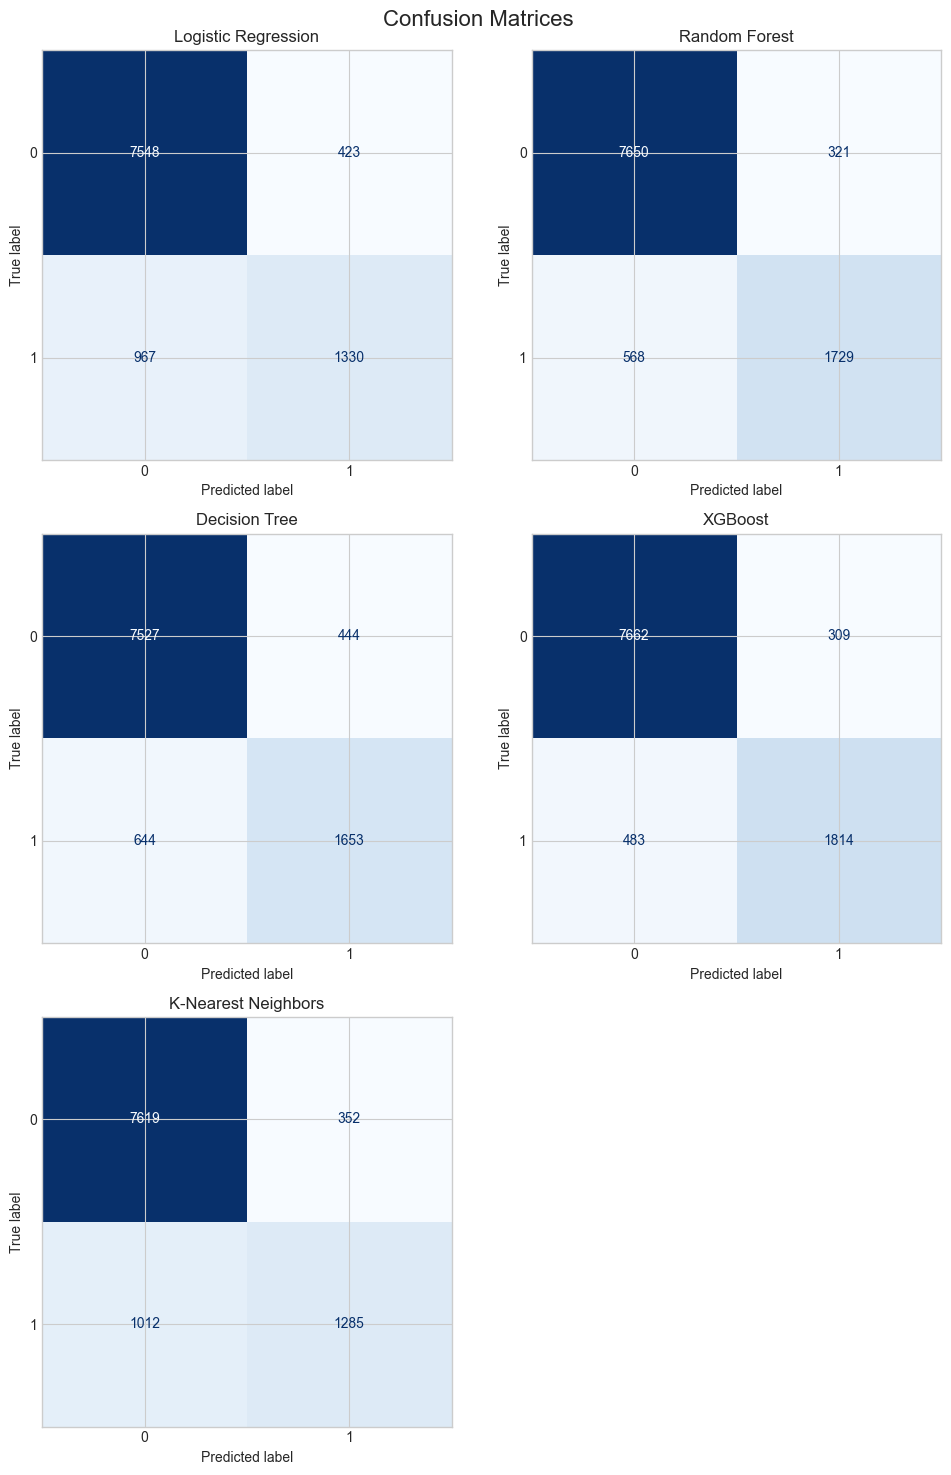

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrices for each model
n_models = len(confusion_matrices)
ncols = 2 if n_models > 1 else 1
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(model_name)

# Hide unused axes when the number of models is not exactly 4 or 6
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# Get the classification report for each models
for model, model_name in MODELS.items():
    print(f"\nClassification Report for {model_name}:")
    y_pred = best_models[model].predict(X_test_scaled)
    print(classification_report(y_test, y_pred))


Classification Report for LogisticRegression(random_state=42):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7971
           1       0.76      0.58      0.66      2297

    accuracy                           0.86     10268
   macro avg       0.82      0.76      0.79     10268
weighted avg       0.86      0.86      0.86     10268


Classification Report for RandomForestClassifier(random_state=42):
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7971
           1       0.84      0.75      0.80      2297

    accuracy                           0.91     10268
   macro avg       0.89      0.86      0.87     10268
weighted avg       0.91      0.91      0.91     10268


Classification Report for DecisionTreeClassifier(random_state=42):
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7971
           1       0.79      0.72    